In [1]:
import os


In [2]:
os.listdir("/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset")

['New Plant Diseases Dataset(Augmented)',
 'new plant diseases dataset(augmented)',
 'test']

In [3]:
dataset_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
os.listdir(dataset_path)

['valid', 'train']

In [4]:
import os

TRAIN_DIR = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR   = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

train_folders = [f for f in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, f))]
val_folders   = [f for f in os.listdir(VAL_DIR) if os.path.isdir(os.path.join(VAL_DIR, f))]

print("Train folder count :", len(train_folders))
print("Validation folder count :", len(val_folders))

print("\nTrain class names:")
print(train_folders)

print("\nValidation class names:")
print(val_folders)

Train folder count : 38
Validation folder count : 38

Train class names:
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

2026-04-06 18:02:06.369584: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775498526.744881      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775498526.861878      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775498527.760321      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775498527.760360      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775498527.760363      55 computation_placer.cc:177] computation placer alr

In [6]:
import tensorflow as tf

# Mixed Precision (for faster training)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Constants
IMG_SIZE = 192
BATCH_SIZE = 16
EPOCHS = 75

# Dataset paths
train_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir   = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Class info
class_names = train_ds.class_names
num_classes = len(class_names)

# AUTOTUNE for performance
AUTOTUNE = tf.data.AUTOTUNE

# Shuffle training data
# Prefetch (performance optimization)
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

Found 70295 files belonging to 38 classes.


I0000 00:00:1775498637.690970      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775498637.696960      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.


In [7]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x) 
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax", dtype='float32')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
         "accuracy",
          tf.keras.metrics.Precision(name="prec"),
          tf.keras.metrics.Recall(name="rec")
     ]
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/75


I0000 00:00:1775498716.307429     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


4394/4394 ━━━━━━━━━━━━━━━━━━━━ 421s 75ms/step - accuracy: 0.5776 - loss: 2.0467 - prec: 0.7945 - rec: 0.4204 - val_accuracy: 0.9017 - val_loss: 1.0930 - val_prec: 0.9604 - val_rec: 0.8186 - learning_rate: 3.0000e-04
Epoch 2/75
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 331s 73ms/step - accuracy: 0.8236 - loss: 1.3119 - prec: 0.9295 - rec: 0.6747 - val_accuracy: 0.9124 - val_loss: 1.0624 - val_prec: 0.9618 - val_rec: 0.8404 - learning_rate: 3.0000e-04
Epoch 3/75
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 335s 73ms/step - accuracy: 0.8496 - loss: 1.2398 - prec: 0.9427 - rec: 0.7076 - val_accuracy: 0.9171 - val_loss: 1.0474 - val_prec: 0.9608 - val_rec: 0.8541 - learning_rate: 3.0000e-04
Epoch 4/75
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 332s 73ms/step - accuracy: 0.8661 - loss: 1.1978 - prec: 0.9477 - rec: 0.7300 - val_accuracy: 0.9334 - val_loss: 1.0007 - val_prec: 0.9687 - val_rec: 0.8742 - learning_rate: 3.0000e-04
Epoch 5/75
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 329s 72ms/step - accuracy: 0.8735 - loss: 1.1777 - prec: 0.95

In [8]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-120:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
         "accuracy",
          tf.keras.metrics.Precision(name="prec"),
          tf.keras.metrics.Recall(name="rec")
     ]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)
model.save("plant_disease_model.keras")

Epoch 1/25
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 482s 97ms/step - accuracy: 0.9480 - loss: 0.6371 - prec: 0.9746 - rec: 0.8906 - val_accuracy: 0.9774 - val_loss: 0.5256 - val_prec: 0.9846 - val_rec: 0.9654 - learning_rate: 5.0000e-06
Epoch 2/25
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 418s 92ms/step - accuracy: 0.9610 - loss: 0.5899 - prec: 0.9792 - rec: 0.9228 - val_accuracy: 0.9812 - val_loss: 0.5090 - val_prec: 0.9860 - val_rec: 0.9716 - learning_rate: 5.0000e-06
Epoch 3/25
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 415s 92ms/step - accuracy: 0.9688 - loss: 0.5667 - prec: 0.9841 - rec: 0.9349 - val_accuracy: 0.9830 - val_loss: 0.4996 - val_prec: 0.9879 - val_rec: 0.9756 - learning_rate: 5.0000e-06
Epoch 4/25
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 414s 91ms/step - accuracy: 0.9734 - loss: 0.5542 - prec: 0.9866 - rec: 0.9405 - val_accuracy: 0.9854 - val_loss: 0.4913 - val_prec: 0.9894 - val_rec: 0.9785 - learning_rate: 5.0000e-06
Epoch 5/25
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 413s 91ms/step - accuracy: 0.9760 - loss: 0.5432 -

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score

yt, yp = [], []

for x, y in val_ds:
    p = model.predict(x, verbose=0)
    yt.extend(np.argmax(y.numpy(), axis=1))
    yp.extend(np.argmax(p, axis=1))

f1 = f1_score(yt, yp, average="weighted")
precision = precision_score(yt, yp, average="weighted")
recall = recall_score(yt, yp, average="weighted")

print("F1 Score   :", f1)
print("Precision  :", precision)
print("Recall     :", recall)

F1 Score   : 0.9949988360488617
Precision  : 0.9950586212578599
Recall     : 0.9949920327794218


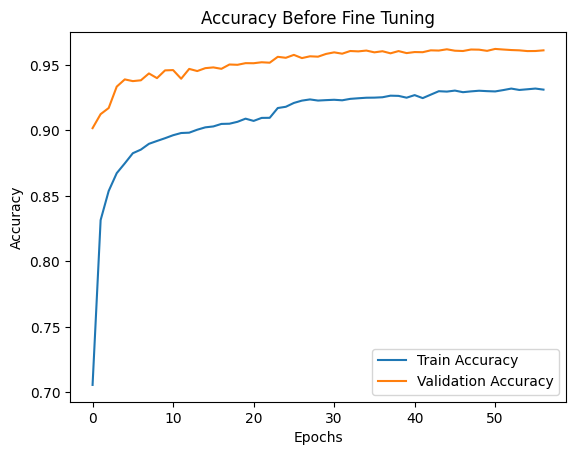

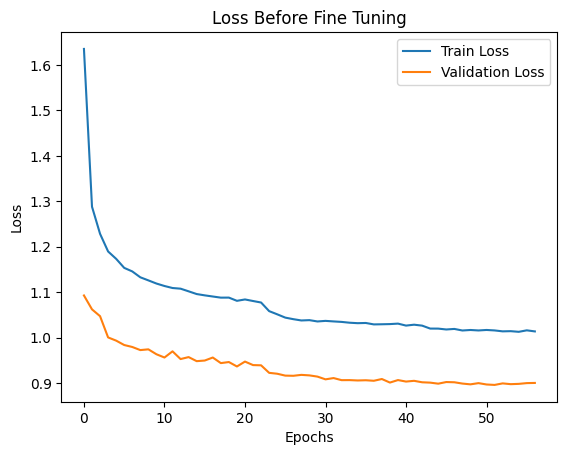

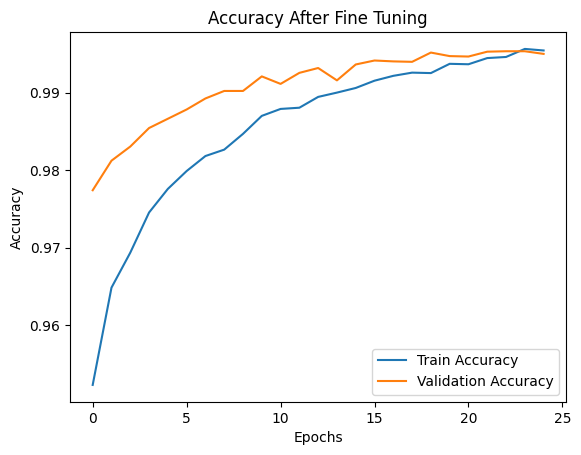

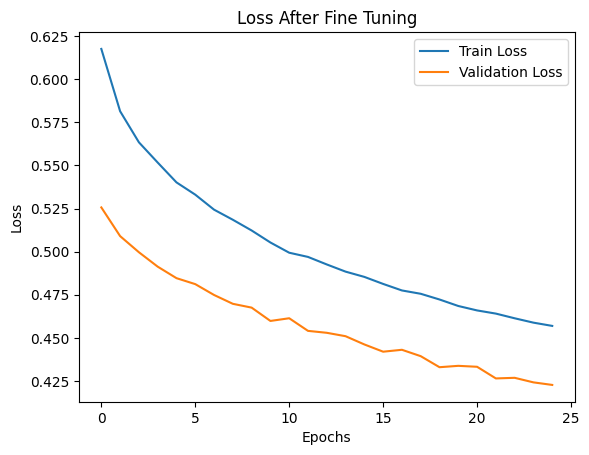

In [10]:
import matplotlib.pyplot as plt

# BEFORE FINE TUNING
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Before Fine Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Before Fine Tuning")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()


# AFTER FINE TUNING
plt.figure()
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.title("Accuracy After Fine Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


plt.figure()
plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])
plt.title("Loss After Fine Tuning")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

In [24]:
import tensorflow as tf
import numpy as np

# Load test dataset (no labels)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=None,
    shuffle=False
)

# Preprocessing
def preprocess(x):
    x = tf.cast(x, tf.float32)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    return x

test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# 🔥 TTA (Test Time Augmentation)
def predict_with_tta(model, x):
    preds = []
    
    preds.append(model.predict(x, verbose=0))
    preds.append(model.predict(tf.image.flip_left_right(x), verbose=0))
    preds.append(model.predict(tf.image.flip_up_down(x), verbose=0))
    
    return np.mean(preds, axis=0)

# 🔥 Sharpen predictions (increase confidence)
def sharpen(preds, temp=0.7):
    preds = np.log(preds + 1e-8) / temp
    preds = np.exp(preds)
    return preds / np.sum(preds, axis=1, keepdims=True)

# 🔥 Run predictions + collect confidence
all_conf = []

for x in test_ds:
    preds = predict_with_tta(model, x)
    preds = sharpen(preds)   # apply sharpening
    
    conf = np.max(preds, axis=1)
    all_conf.extend(conf)

# 🔥 Mean confidence
mean_conf = np.mean(all_conf)

print(f"\n🔥 Boosted Mean Confidence: {mean_conf*100:.2f}%")

Found 252 files.

🔥 Boosted Mean Confidence: 65.31%


In [25]:
import tensorflow as tf

# Load dataset WITHOUT labels
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=None,
    shuffle=False
)

# Add preprocessing + dummy labels
def preprocess_and_add_dummy(x):
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    
    # Dummy labels (same shape as model output)
    dummy_y = tf.zeros((tf.shape(x)[0], len(class_names)))
    
    return x, dummy_y

test_ds = test_ds.map(preprocess_and_add_dummy, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Prediction (works without error)
predictions = model.predict(test_ds)

Found 252 files.
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step


In [26]:
for x, _ in test_ds:   # ignore dummy labels
    preds = model.predict(x, verbose=0)

    for i in range(len(preds)):
        top_class = np.argmax(preds[i])
        confidence = np.max(preds[i])

        print(f"Predicted class: {class_names[top_class]}, Confidence: {confidence:.2f}")

Predicted class: Strawberry___Leaf_scorch, Confidence: 0.36
Predicted class: Apple___Apple_scab, Confidence: 0.93
Predicted class: Strawberry___Leaf_scorch, Confidence: 0.47
Predicted class: Potato___Early_blight, Confidence: 0.21
Predicted class: Apple___Apple_scab, Confidence: 0.47
Predicted class: Potato___Early_blight, Confidence: 0.14
Predicted class: Pepper,_bell___Bacterial_spot, Confidence: 0.16
Predicted class: Apple___healthy, Confidence: 0.21
Predicted class: Strawberry___Leaf_scorch, Confidence: 0.15
Predicted class: Strawberry___Leaf_scorch, Confidence: 0.56
Predicted class: Apple___healthy, Confidence: 0.82
Predicted class: Apple___healthy, Confidence: 0.78
Predicted class: Pepper,_bell___Bacterial_spot, Confidence: 0.45
Predicted class: Apple___healthy, Confidence: 0.63
Predicted class: Apple___healthy, Confidence: 0.39
Predicted class: Apple___Black_rot, Confidence: 0.26
Predicted class: Potato___healthy, Confidence: 0.40
Predicted class: Squash___Powdery_mildew, Confid

In [27]:
import numpy as np

all_confidences = []

for x, _ in test_ds:
    preds = model.predict(x, verbose=0)

    # get max confidence for each image in batch
    conf = np.max(preds, axis=1)
    all_confidences.extend(conf)

# calculate mean
mean_conf = np.mean(all_confidences)

print(f"\nMean Confidence: {mean_conf:.4f}")


Mean Confidence: 0.5123


In [ ]:
import matplotlib.pyplot as plt

classes = list(class_acc.keys())
accuracies = list(class_acc.values())

plt.figure(figsize=(20, 8))
plt.bar(classes, accuracies)

plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Classes")
plt.title("Per-Class Accuracy on Test Dataset")

plt.tight_layout()
plt.show()